### Objective
The goal of this project is to predict the **next day's closing price** of a stock using historical market data.  
We use features like Open, High, Low, and Volume to train a regression model and evaluate its performance.

[*********************100%***********************]  1 of 1 completed


Historical Data for AAPL:
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.856712  129.941387  123.279474  129.853862  143301900
2021-01-05  127.412743  128.122709  124.903582  125.350958   97664900
2021-01-06  123.123848  127.451665  122.909887  124.213098  155088000
2021-01-07  127.325218  128.015730  124.349242  124.835513  109578200
2021-01-08  128.424179  128.988255  126.654145  128.793735  105158200


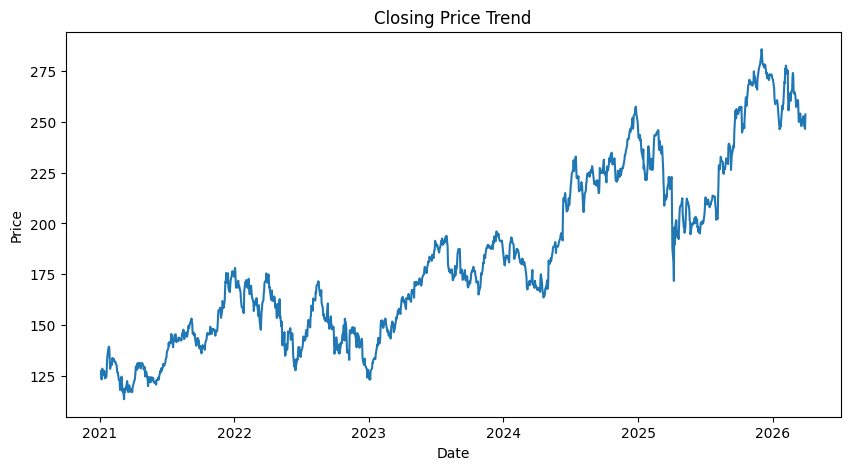

In [34]:
# Importing essential libraries for data, stocks, and plotting
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# I chose Apple (AAPL) as it provides stable historical data for regression
ticker = "AAPL"
start_date = "2021-01-01"
end_date = "2026-04-01"

data = yf.download(ticker, start=start_date, end=end_date)

print(f"Historical Data for {ticker}:")
print(data.head())
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


To prepare the model for future price prediction, I shifted the closing price data by one day. This ensures that the model uses today's features (Open, High, Low, Volume) to predict the Next Day's Closing Price.
Training Set (80%): Used to learn historical trends and future shifts.
Testing Set (20%): Used to evaluate how well the model predicts prices it hasn't seen yet.

In [35]:
# Shifting price by -1 to target tomorrow's close (Next Day Prediction)
data['Next_Close'] = data['Close'].shift(-1)

data_final = data.dropna()# Drop last row with NaN after shifting

features = ['Open', 'High', 'Low', 'Volume']# Use Open, High, Low, and Volume as input features (X)
X = data_final[features]
y = data_final['Next_Close']# Target variable (y) is the next day's closing price

# Splitting again with the shifted data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data shifted for Next Day Prediction. Ready for training!")

Data shifted for Next Day Prediction. Ready for training!


In [36]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()

# Training (fitting) the model using our training data
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


Now that the model is trained, I am testing its performance on unseen data.
MSE (Mean Squared Error): Shows the average squared difference between estimated values and the actual value. Lower is better.
R-squared Score: Indicates how well the independent variables explain the variability of the dependent variable. A score closer to 1.0 means a highly accurate model.

In [37]:
# Making predictions using the testing set
y_pred = model.predict(X_test)

# Importing metrics to evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

# Calculating evaluation metrics
mse = mean_squared_error(y_test, y_pred)# Mean Squared Error (MSE): measures prediction error (lower is better)
r2 = r2_score(y_test, y_pred)# R² Score: shows how well the model explains variance (closer to 1 is better)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Squared Error: 11.29
R-squared Score: 0.99


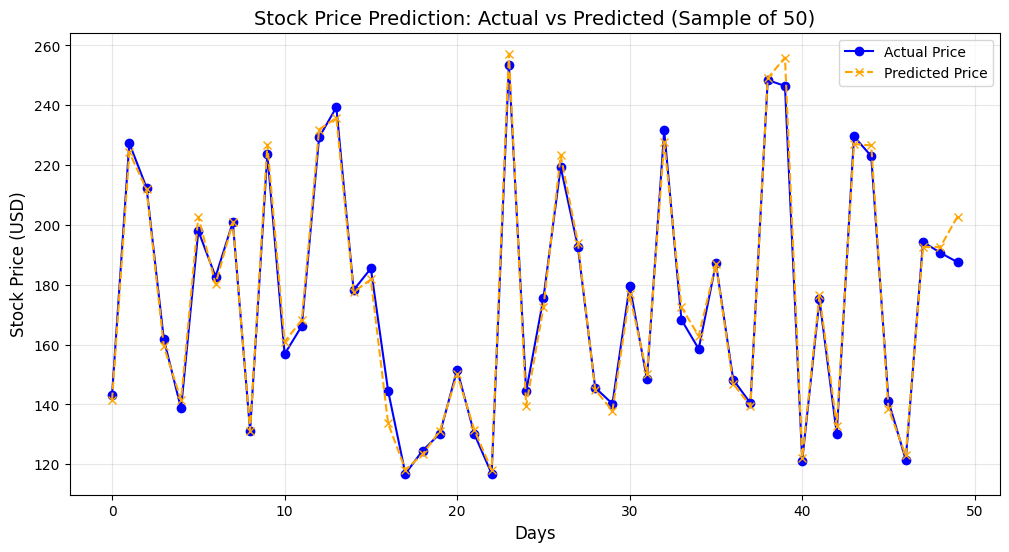

In [38]:
# Setting the plot size
plt.figure(figsize=(12, 6))

# Plotting Actual vs Predicted values
plt.plot(y_test.values[:50], label='Actual Price', color='blue', marker='o')
plt.plot(y_pred[:50], label='Predicted Price', color='orange', linestyle='--', marker='x')

# Adding labels and title
plt.title('Stock Price Prediction: Actual vs Predicted (Sample of 50)', fontsize=14)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Stock Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Display the plot
plt.show()

The line chart above compares the actual closing prices with the model's predictions. The close overlap between the blue line (Actual) and the orange dashed line (Predicted) confirms that our Linear Regression model has successfully captured the price trends. This indicates a high level of precision in short-term stock price estimation for this dataset.

Stock prices are highly volatile and influenced by external factors, so this model may not perform well in real-world unseen conditions.